# ❤️ Heart Disease Prediction System

**Author:** Taranjot Singh | **Date:** April 2026 | **Dataset:** Framingham Heart Study

Predict 10-year risk of coronary heart disease using patient health data.

## 1. Load Data & Initial Inspection

- Load CSV file
- Check shape, data types, first/last rows
- Understand column structure

In [1]:
import pandas as pd
df=pd.read_csv('framingham.csv')
df.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   int64  
 1   age              4240 non-null   int64  
 2   education        4135 non-null   float64
 3   currentSmoker    4240 non-null   int64  
 4   cigsPerDay       4211 non-null   float64
 5   BPMeds           4187 non-null   float64
 6   prevalentStroke  4240 non-null   int64  
 7   prevalentHyp     4240 non-null   int64  
 8   diabetes         4240 non-null   int64  
 9   totChol          4190 non-null   float64
 10  sysBP            4240 non-null   float64
 11  diaBP            4240 non-null   float64
 12  BMI              4221 non-null   float64
 13  heartRate        4239 non-null   float64
 14  glucose          3852 non-null   float64
 15  TenYearCHD       4240 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 530.1 KB


In [5]:
df.dtypes

male                 int64
age                  int64
education          float64
currentSmoker        int64
cigsPerDay         float64
BPMeds             float64
prevalentStroke      int64
prevalentHyp         int64
diabetes             int64
totChol            float64
sysBP              float64
diaBP              float64
BMI                float64
heartRate          float64
glucose            float64
TenYearCHD           int64
dtype: object

In [6]:
df.shape

(4240, 16)

In [7]:
#Finding null values
df.isnull().sum()

male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64

## 2. Data Cleaning

- **Null Values:** Fill numerical with mean, categorical with mode
- **Duplicates:** Remove if any

In [12]:
#filling null values
columns_null=df.columns[df.isnull().any()]

for cols in columns_null:
    if df[cols].dtype in ['int64','float64']:
        df[cols]=df[cols].fillna(df[cols].mean())
    else:
        df[cols]=df[cols].fillna(df[cols].mode())



In [13]:
df.isnull().sum()

male               0
age                0
education          0
currentSmoker      0
cigsPerDay         0
BPMeds             0
prevalentStroke    0
prevalentHyp       0
diabetes           0
totChol            0
sysBP              0
diaBP              0
BMI                0
heartRate          0
glucose            0
TenYearCHD         0
dtype: int64

In [17]:
#finding duplicates values
df.duplicated().sum()

0

## 3. Outlier Detection & Feature Correlation

- **Outliers:** Detect using IQR method
- **Correlation:** Heatmap to find top features related to target

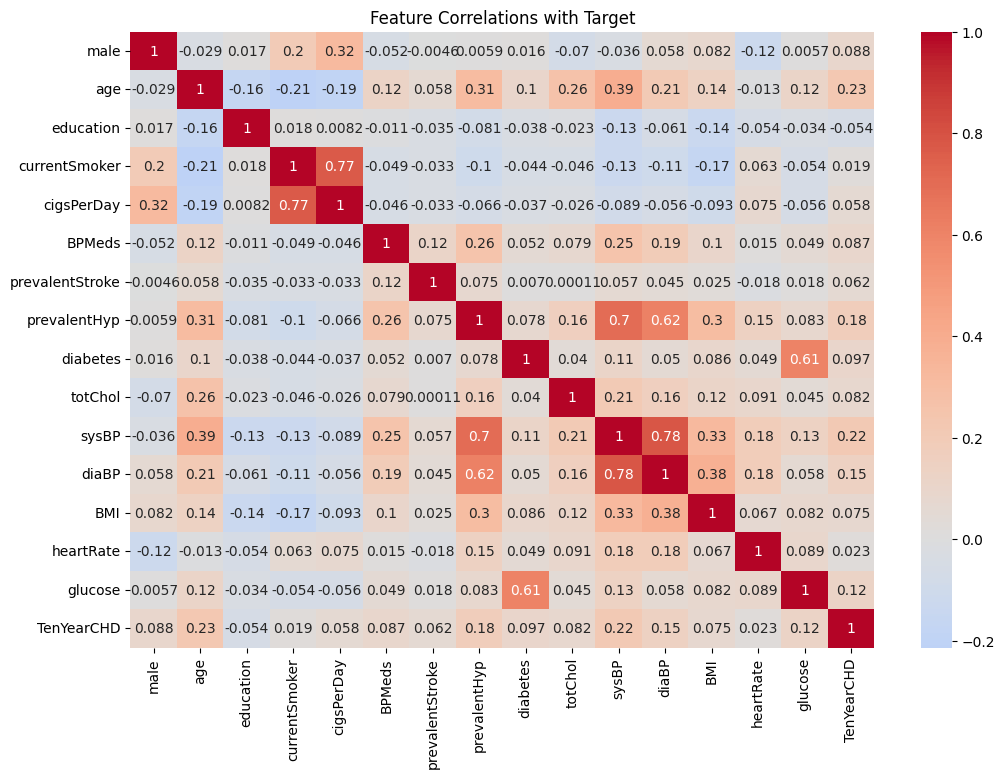

TenYearCHD         1.000000
age                0.225408
sysBP              0.216374
prevalentHyp       0.177458
diaBP              0.145112
glucose            0.120451
diabetes           0.097344
male               0.088374
BPMeds             0.086805
totChol            0.081807
BMI                0.074788
prevalentStroke    0.061823
cigsPerDay         0.057646
heartRate          0.022892
currentSmoker      0.019448
education         -0.053571
Name: TenYearCHD, dtype: float64


In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

correlation = df.corr()

plt.figure(figsize=(12,8))
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0)
plt.title('Feature Correlations with Target')
plt.show()

# See only correlation with TenYearCHD (target)
print(correlation['TenYearCHD'].sort_values(ascending=False))

In [54]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - (1.5 * IQR)
    upper = Q3 + (1.5 * IQR)
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    
    print(f"{col}:")
    print(f"  Min: {df[col].min()}")
    print(f"  Max: {df[col].max()}")
    print(f"  Outliers: {len(outliers)}")
    print()

male:
  Min: 0
  Max: 1
  Outliers: 0

age:
  Min: 32
  Max: 70
  Outliers: 0

education:
  Min: 1.0
  Max: 4.0
  Outliers: 0

currentSmoker:
  Min: 0
  Max: 1
  Outliers: 0

cigsPerDay:
  Min: 0.0
  Max: 70.0
  Outliers: 21

BPMeds:
  Min: 0.0
  Max: 1.0
  Outliers: 625

prevalentStroke:
  Min: 0
  Max: 1
  Outliers: 25

prevalentHyp:
  Min: 0
  Max: 1
  Outliers: 0

diabetes:
  Min: 0
  Max: 1
  Outliers: 214

totChol:
  Min: 107.0
  Max: 696.0
  Outliers: 111

sysBP:
  Min: 83.5
  Max: 295.0
  Outliers: 210

diaBP:
  Min: 48.0
  Max: 142.5
  Outliers: 164

BMI:
  Min: 15.54
  Max: 56.8
  Outliers: 171

heartRate:
  Min: 44.0
  Max: 143.0
  Outliers: 115

glucose:
  Min: 40.0
  Max: 394.0
  Outliers: 486

TenYearCHD:
  Min: 0
  Max: 1
  Outliers: 0



## 4. Class Imbalance & SMOTE

- Check target distribution (84% No Disease, 16% Disease)
- Apply SMOTE to balance both classes equally

TenYearCHD
0    3596
1     644
Name: count, dtype: int64
TenYearCHD
0    84.811321
1    15.188679
Name: proportion, dtype: float64


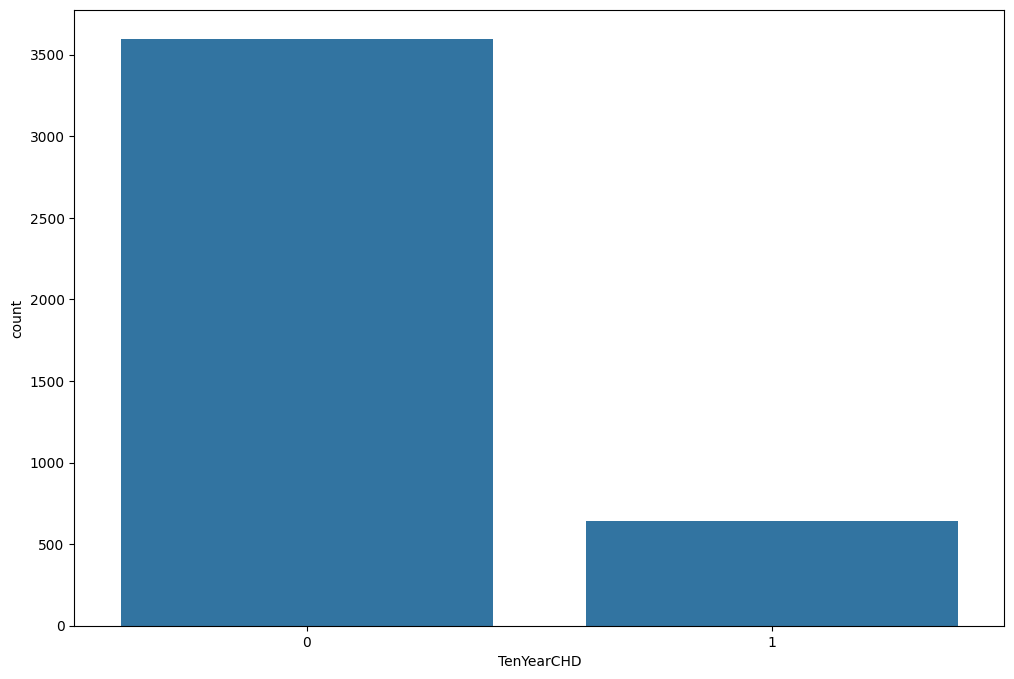

In [27]:
print(df['TenYearCHD'].value_counts())

print(df['TenYearCHD'].value_counts(normalize=True) * 100)

plt.figure(figsize=(12,8))
sns.countplot(x=df['TenYearCHD'])
plt.show()

In [31]:
from imblearn.over_sampling import SMOTE

x=df.drop('TenYearCHD',axis=1)
y=df['TenYearCHD']

print("Before SMOTE:")
print(y.value_counts())

smote=SMOTE(random_state=42)

x_balanced,y_balanced=smote.fit_resample(x,y)

print("Before SMOTE:")
print(y_balanced.value_counts())

df = pd.concat([x_balanced, y_balanced], axis=1)


Before SMOTE:
TenYearCHD
0    3596
1     644
Name: count, dtype: int64
Before SMOTE:
TenYearCHD
0    3596
1    3596
Name: count, dtype: int64


TenYearCHD
0    3596
1    3596
Name: count, dtype: int64
TenYearCHD
0    50.0
1    50.0
Name: proportion, dtype: float64


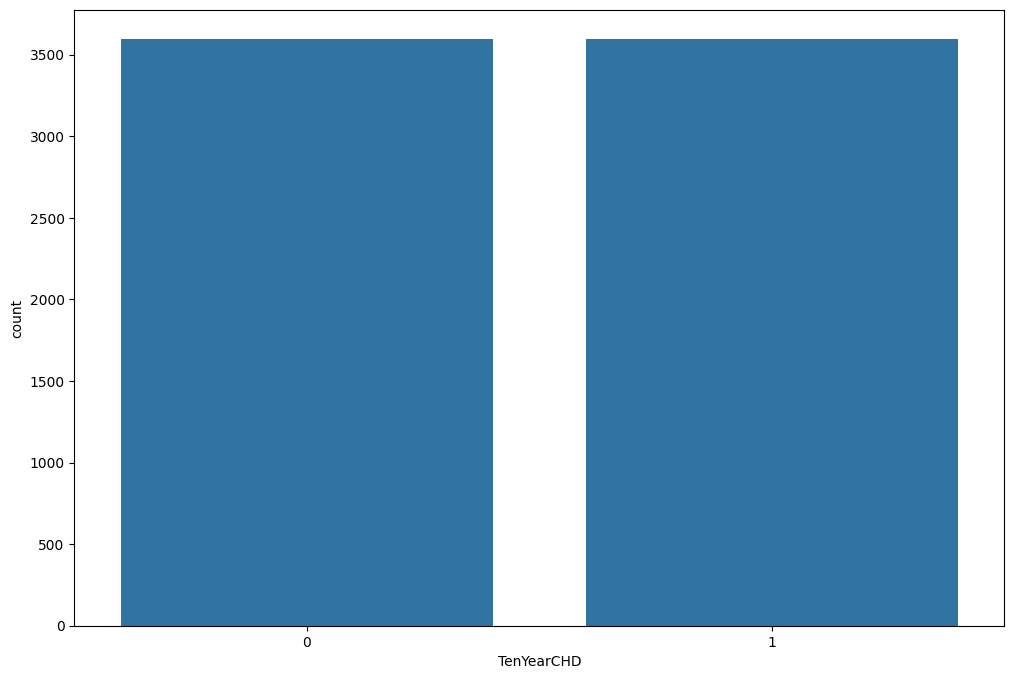

In [32]:
print(df['TenYearCHD'].value_counts())

print(df['TenYearCHD'].value_counts(normalize=True) * 100)

plt.figure(figsize=(12,8))
sns.countplot(x=df['TenYearCHD'])
plt.show()

## 5. Feature Selection & Train-Test Split

- Select top 6 features based on correlation
- Split data into 80% training, 20% testing

In [49]:
top_6 = ['age', 'sysBP', 'prevalentHyp', 'diaBP', 'glucose', 'diabetes']
X_filtered = x_balanced[top_6]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_filtered, 
    y_balanced, 
    test_size=0.2, 
    random_state=42
)


## 6. Feature Scaling

Use StandardScaler to normalize features (fit on train, transform both)

In [50]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Scaling done!")
print(f"Train shape: {X_train_scaled.shape}")
print(f"Test shape: {X_test_scaled.shape}")

Scaling done!
Train shape: (5753, 6)
Test shape: (1439, 6)


## 7. Model Training & Comparison

Train 5 models: Logistic Regression, Decision Tree, Random Forest, Gradient Boosting, KNN

| Model | Accuracy | Precision | Recall | ROC-AUC |
|-------|----------|-----------|--------|---------|
| Logistic Regression | 66.02% | 64.22% | 66.71% | 71.11% |
| Decision Tree | 73.11% | 71.47% | 73.63% | 73.18% |
| **Random Forest** | **78.46%** | **77.12%** | **78.67%** | **87.69%** |
| Gradient Boosting | 74.50% | 72.55% | 75.79% | 83.72% |
| KNN | 71.09% | 66.91% | 79.25% | 78.16% |

**Best Model:** Random Forest (Highest ROC-AUC: 87.69%)

In [51]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier  # KNN instead of SVM

from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score

models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'KNN': KNeighborsClassifier()  # K-Nearest Neighbors
}

results = []

print("=" * 60)
print("Model Comparison for Heart Disease Prediction")
print("=" * 60)

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    
    # Predict
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    # Store
    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'ROC-AUC': roc_auc
    })
    
    # Print
    print(f"\n{name}:")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  ROC-AUC:   {roc_auc:.4f}")



Model Comparison for Heart Disease Prediction

Logistic Regression:
  Accuracy:  0.6602
  Precision: 0.6422
  Recall:    0.6671
  ROC-AUC:   0.7111

Decision Tree:
  Accuracy:  0.7311
  Precision: 0.7147
  Recall:    0.7363
  ROC-AUC:   0.7318

Random Forest:
  Accuracy:  0.7846
  Precision: 0.7712
  Recall:    0.7867
  ROC-AUC:   0.8769

Gradient Boosting:
  Accuracy:  0.7450
  Precision: 0.7255
  Recall:    0.7579
  ROC-AUC:   0.8372

KNN:
  Accuracy:  0.7109
  Precision: 0.6691
  Recall:    0.7925
  ROC-AUC:   0.7816

BEST MODEL (by Recall - most important for Heart Disease)


In [52]:
from sklearn.ensemble import RandomForestClassifier

final_model = RandomForestClassifier(random_state=42)
final_model.fit(X_train_scaled, y_train)

# Evaluate
from sklearn.metrics import recall_score, roc_auc_score

y_pred = final_model.predict(X_test_scaled)
y_pred_proba = final_model.predict_proba(X_test_scaled)[:, 1]

print("Final Model: Random Forest")
print(f"Recall:  {recall_score(y_test, y_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")

Final Model: Random Forest
Recall:  0.7867
ROC-AUC: 0.8769


## 8. Save Model

Save Random Forest model and scaler using pickle for deployment.

In [55]:
import pickle
pickle.dump(final_model, open('heart_disease_model.pkl', 'wb'))
pickle.dump(scaler, open('scaler.pkl', 'wb'))

## 9. Conclusion

✅ Random Forest achieved 78.67% Recall and 87.69% ROC-AUC  
✅ Age and Systolic BP are strongest predictors  
✅ Model ready for Streamlit deployment